# Linear regression

Linear regression estimates the relationship between an input and a numeric target with a line. With one feature, the model has two parameters: a slope that controls how the prediction changes with the feature and an intercept that sets its value when the feature is zero. The objective is to choose those parameters so that the predictions are close to the observed targets under a specified loss.

The data in this notebook are generated from a known line with Gaussian noise. That gives us two references. We can check whether gradient descent recovers the underlying trend, and we can compare its result with the least-squares solution. The noise also makes clear what the fitted line is and is not supposed to do: it estimates the conditional trend; it is not expected to pass through every observation.


## The model and loss

For one feature, the prediction for an input `x` is

```text
y_hat = wx + b
```

Here `w` is the slope and `b` is the intercept. For a dataset of `n` observations, mean squared error is

```text
MSE(w, b) = (1/n) sum_i (w x_i + b - y_i)^2
```

The residual for an observation is `y_hat_i - y_i`. Squaring removes the sign and gives larger residuals more influence. The loss is a convex quadratic in `w` and `b`, so it has one global minimum unless the design matrix is degenerate.


## The data-generating relationship

The observations are sampled from

```text
y = 2.5x + 0.8 + noise
```

The feature values are drawn uniformly from `[-3, 3]`, and the noise is Gaussian with standard deviation `0.8`. The noise-free line is therefore known: slope `2.5`, intercept `0.8`. The training and test sets are generated independently. The test set is not used to compute the updates; it provides a separate check of how well the learned line captures the generating relationship.

Before fitting, it is useful to keep the roles distinct. The generating line is the population relationship used to create the experiment. The fitted line is estimated from one finite noisy sample. The least-squares reference is a direct numerical solution for that sample.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(23)
x_train = rng.uniform(-3, 3, 120)
y_train = 2.5 * x_train + 0.8 + rng.normal(scale=0.8, size=len(x_train))
x_test = rng.uniform(-3, 3, 80)
y_test = 2.5 * x_test + 0.8 + rng.normal(scale=0.8, size=len(x_test))


def mse(y, prediction):
    return np.mean((prediction - y) ** 2)


def fit_gd(x, y, eta=0.03, steps=200):
    w, b = 0.0, 0.0
    history = []
    for _ in range(steps):
        prediction = w * x + b
        residual = prediction - y
        history.append((w, b, mse(y, prediction)))
        w -= eta * 2 * np.mean(residual * x)
        b -= eta * 2 * np.mean(residual)
    history.append((w, b, mse(y, w * x + b)))
    return np.array(history)

history = fit_gd(x_train, y_train)
print('initial w, b, mse:', history[0])
print('final   w, b, mse:', history[-1])

Matplotlib is building the font cache; this may take a moment.


initial w, b, mse: [ 0.          0.         19.01214625]
final   w, b, mse: [2.50028673 0.83801567 0.67839124]


## Fitting the model with gradient descent

The training loop starts at `w = 0` and `b = 0`. At each step it computes all predictions, forms the residuals, records the current loss, and updates both parameters using the gradient of the training MSE. The code prints the first and last recorded states so the scale of the optimization can be inspected before looking at a plot.

For this seed, the final parameters should be close to `w = 2.5` and `b = 0.8`. They will not be exactly equal because the finite sample contains noise. The final training MSE is the average squared vertical distance from the fitted line to the training observations.


## The parameter updates

Differentiating the loss gives

```text
dMSE/dw = 2 mean((wx + b - y) x)
dMSE/db = 2 mean(wx + b - y)
```

The slope gradient is a residual-feature correlation. If positive and negative residuals are not balanced across the feature range, changing the slope can reduce the loss. The intercept gradient is the mean residual, so it shifts the line vertically when predictions are systematically too high or too low. Both derivatives are computed from the same training observations at every update.


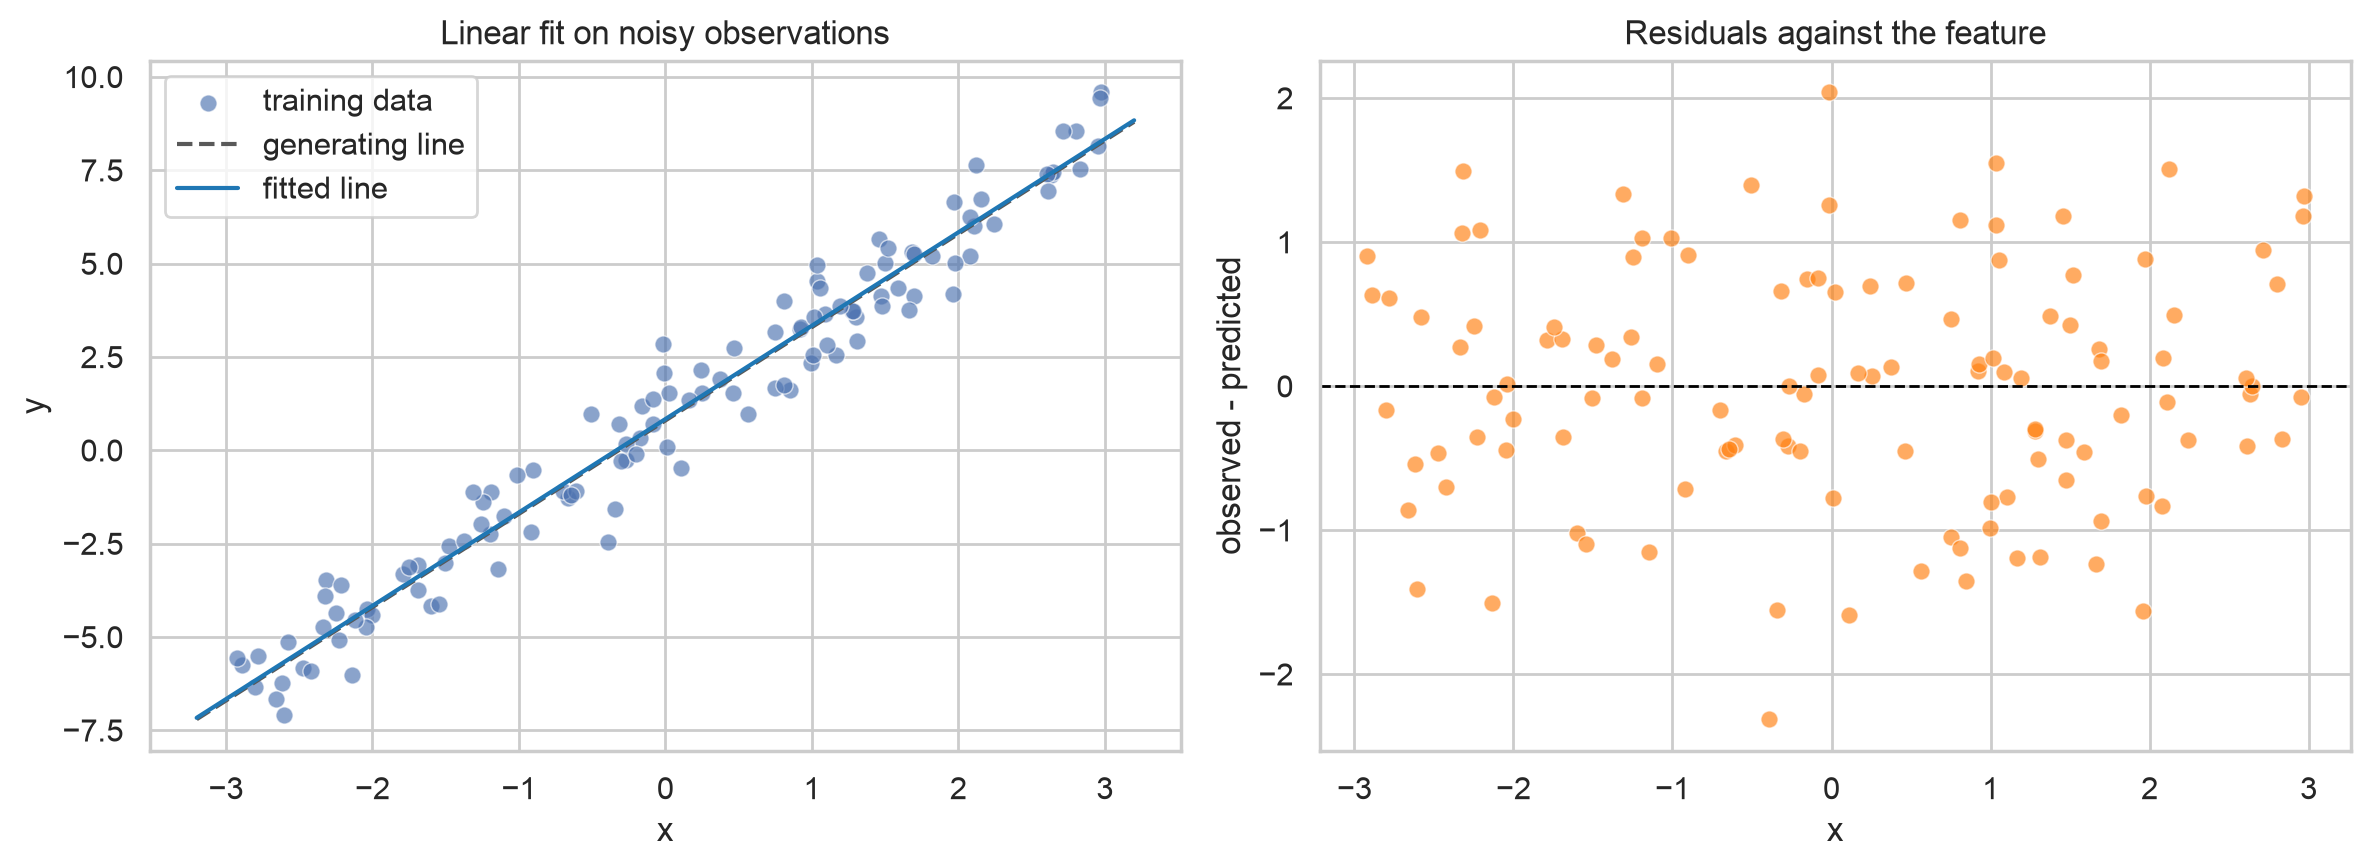

In [2]:
import pandas as pd
import seaborn as sns

grid = np.linspace(-3.2, 3.2, 200)
prediction = history[-1, 0] * x_train + history[-1, 1]
residual = y_train - prediction
plot_data = pd.DataFrame({"x": x_train, "y": y_train, "residual": residual})

sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=plot_data, x="x", y="y", s=38, alpha=0.65, ax=axes[0], label="training data")
axes[0].plot(grid, 2.5 * grid + 0.8, "--", color="0.35", label="generating line")
axes[0].plot(grid, history[-1, 0] * grid + history[-1, 1], color="tab:blue", label="fitted line")
axes[0].set(title="Linear fit on noisy observations", xlabel="x", ylabel="y")
axes[0].legend()
sns.scatterplot(data=plot_data, x="x", y="residual", s=38, alpha=0.65, color="tab:orange", ax=axes[1])
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set(title="Residuals against the feature", xlabel="x", ylabel="observed - predicted")
fig.tight_layout()
plt.show()


In [3]:
augmented = np.column_stack([x_train, np.ones(len(x_train))])
reference = np.linalg.lstsq(augmented, y_train, rcond=None)[0]
w_gd, b_gd = history[-1, :2]
train_prediction = w_gd * x_train + b_gd
test_prediction = w_gd * x_test + b_gd
print('gradient descent:', {'w': w_gd, 'b': b_gd})
print('least squares:   ', {'w': reference[0], 'b': reference[1]})
print('parameter distance:', np.linalg.norm(np.array([w_gd, b_gd]) - reference))
print('train RMSE:', np.sqrt(mse(y_train, train_prediction)))
print('test RMSE: ', np.sqrt(mse(y_test, test_prediction)))

gradient descent: {'w': np.float64(2.500286727564937), 'b': np.float64(0.8380156718556058)}
least squares:    {'w': np.float64(2.500286614061711), 'b': np.float64(0.8380189271791606)}
parameter distance: 3.2573017098549746e-06
train RMSE: 0.8236450962990406
test RMSE:  0.7550071196710899


## Inspecting the fitted line and residuals

The first panel compares the noisy observations with the known generating line and the line learned by gradient descent. The second panel plots residuals against `x`. A fitted linear model should leave residuals centered around zero without a systematic curve or widening pattern. Random scatter is compatible with the Gaussian-noise assumption; a visible pattern would suggest that a straight line is missing structure.


## Least squares and held-out error

For this problem, the same optimum can be obtained directly with least squares. Adding a column of ones turns the model into a matrix equation, `X beta`, where `beta = [w, b]`. `np.linalg.lstsq` solves the finite-sample least-squares problem without taking iterative steps. Agreement between its parameters and the gradient-descent parameters checks the implementation.

The train and test RMSE values should be similar because both sets come from the same distribution. The test error is not expected to be zero: the target includes new noise, and no deterministic line can predict an independent noise draw. A large gap between training and test error would indicate a generalization problem; here the two-parameter model has little capacity for that kind of overfitting.
